# KNN and Performance Metrics

In [1]:
''' LINEAR ALGEBRA '''
import numpy as np
import pandas as pd

''' DATA VISUALISATION '''
import matplotlib.pyplot as plt
import seaborn as sns

''' SKLEARN '''

''' Imputer'''
from sklearn.impute import SimpleImputer

''' Holdout Methods and Cross validation'''
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate

''' Regression Models'''
from sklearn.preprocessing import RobustScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

'''Regression Metrics'''
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, max_error

'''Classification Models'''
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


'''Classification Metrics'''
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


## (1) 🐧 **KNN Classifier**

### (1.1) Dataset + Preparation

Let's play with the 🐧 `Penguins` dataset from Seaborn.

In [2]:
penguins = sns.load_dataset("penguins")
penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


In [3]:
# There are no duplicates
penguins.duplicated().sum()

0

In [4]:
# How many missing values ?
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
# There is only a few missing values, let's impute them
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

num_features = penguins.select_dtypes(exclude = ["object"]).columns
cat_features = penguins.select_dtypes(include = ["object"]).columns

penguins[num_features] = num_imputer.fit_transform(penguins[num_features])
penguins[cat_features] = cat_imputer.fit_transform(penguins[cat_features])

penguins.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [6]:
# Let's define the features and the target
# We want to predict the species of penguins
X = penguins.drop(columns=["species","island","sex"])
y = penguins["species"]

In [7]:
# Let's also encode the target
label_encoder = LabelEncoder()
label_encoder.fit(y)
encoded_target = label_encoder.transform(y)
encoded_target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

### (1.2) Holdout

In [8]:
X_train, X_test, y_train,  y_test = train_test_split(X, encoded_target, test_size = 0.3)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240, 4), (104, 4), (240,), (104,))

In [10]:
pd.Series(y_train).value_counts()
# dataset a bit imbalanced but still fine
# to classify things

0    107
2     92
1     41
dtype: int64

### (1.3) **Classifying** using the KNN algorithm

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate the KNN Classifier, 5 neighbors by default
classifier = KNeighborsClassifier(n_neighbors =5)

# Train it

classifier.fit(X_train, y_train)

KNeighborsClassifier()

### (1.4) Classification Metrics

In [12]:
# Predicting classes
predicted_classes = classifier.predict(X_test)
predicted_classes

array([0, 0, 0, 2, 0, 1, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 0, 1, 0,
       2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 2, 1, 2, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 0, 2, 0,
       0, 2, 2, 0, 1, 1, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 1,
       2, 2, 1, 2, 1, 0, 0, 1, 0, 0, 1, 0, 2, 0, 0, 2])

In [13]:
# Real classes
y_test

array([0, 2, 2, 2, 0, 1, 0, 1, 0, 2, 1, 0, 2, 1, 0, 2, 0, 0, 0, 1, 0, 0,
       2, 0, 1, 0, 2, 0, 1, 1, 0, 2, 2, 2, 0, 1, 2, 2, 2, 1, 1, 0, 1, 0,
       0, 2, 0, 1, 2, 1, 2, 1, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1,
       0, 2, 2, 0, 1, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0,
       2, 2, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 2])

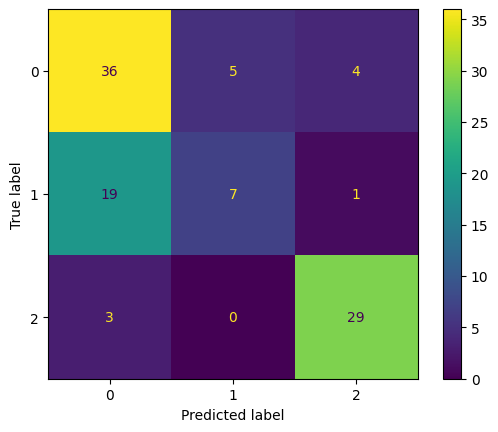

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

#### (1.4.1) Accuracy

`Accuracy` 

= ability of the model to output correct predictions

= sum of the elements on the diagonal matrix divided by the total number of elements in the test set

<u>Computing accuracy with Python</u>

In [15]:
np.diag(cm)

array([36,  7, 29])

In [16]:
np.sum(np.diag(cm))

72

In [17]:
len(y_test)

104

In [18]:
accuracy_python = np.sum(np.diag(cm))/len(y_test)
accuracy_python

0.6923076923076923

<u>Computing accuracy with Sklearn</u>

In [19]:
accuracy_sklearn = accuracy_score(y_test, predicted_classes)
accuracy_sklearn

0.6923076923076923

#### (1.4.2) Recall

`Recall of a class` 

= ability of the model to capture one class

= true positives for a given class divided by the total occurencies of this class

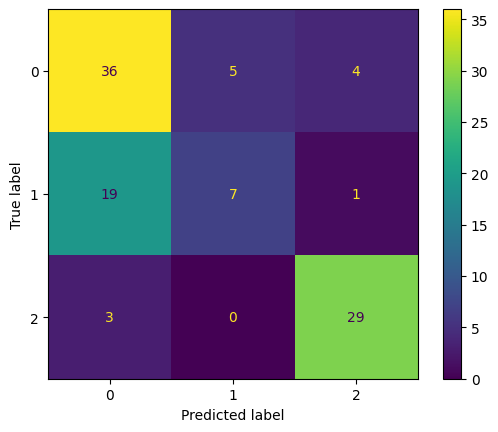

In [20]:
disp.plot()
plt.show()

<u>Recall with Python</u>

*Class 0*

In [21]:
real_zeros = cm[0]
real_zeros

array([36,  5,  4])

In [22]:
total_real_zeros = np.sum(real_zeros)
total_real_zeros

45

In [23]:
correct_predictions_zeros = cm[0][0]
correct_predictions_zeros

36

In [24]:
recall_class_zero = correct_predictions_zeros / total_real_zeros
recall_class_zero

0.8

*Class 1*

In [25]:
real_ones = cm[1]
total_real_ones = np.sum(real_ones)
correct_predictions_ones = cm[1][1]
recall_class_one = correct_predictions_ones / total_real_ones
recall_class_one

0.25925925925925924

In [26]:
real_twos = cm[2]
total_real_twos = np.sum(real_twos)
correct_predictions_twos = cm[2][2]
recall_class_two = correct_predictions_twos / total_real_twos
recall_class_two

0.90625

<u>Recall with Sklearn</u>

Cf. `(1.4.5) Classification report`

#### (1.4.3) Precision

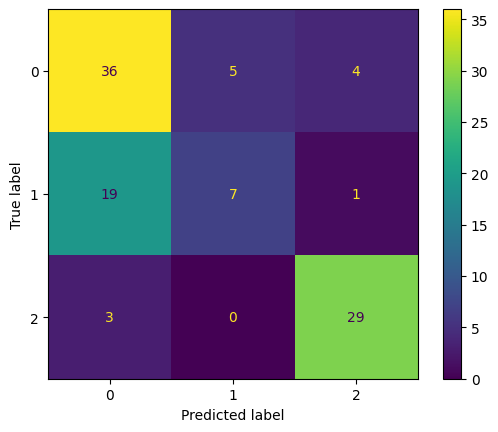

In [27]:
disp.plot()
plt.show()

`Precision of a class` 

= ability of the model to avoid false alarms

= true positives for a given class divided by the total predictions of this class

<u>Precision with Python</u>

*Class 0*

In [28]:
predicted_zeros = cm[:,0]
predicted_zeros

array([36, 19,  3])

In [29]:
total_predicted_zeros = np.sum(predicted_zeros)
total_predicted_zeros

58

In [30]:
correct_predictions_zeros = cm[0][0]
correct_predictions_zeros

36

In [31]:
precision_class_zero = correct_predictions_zeros / total_predicted_zeros
precision_class_zero

0.6206896551724138

*Class 1*

In [32]:
predicted_ones = cm[:,1]
total_predicted_ones = np.sum(predicted_ones)
correct_predictions_ones = cm[1][1]
precision_class_one = correct_predictions_ones / total_predicted_ones
precision_class_one

0.5833333333333334

In [33]:
predicted_twos = cm[:,2]
total_predicted_twos = np.sum(predicted_twos)
correct_predictions_twos = cm[2][2]
precision_class_two = correct_predictions_twos / total_predicted_twos
precision_class_two

0.8529411764705882

<u>Precision with Sklearn</u>

Cf. `(1.4.5) Classification report`

#### (1.4.4) F1-Score

* You cannot increase both the recall and precision by playing with the probability threshold

* However, you can consider the harmonic mean of them to take these two metrics into consideration. This is called the F1-score

* F1-score should also replace accuracy for unbalanced dataset

$ f_1 = \frac{2}{\frac{1}{recall}+\frac{1}{precision}}$

<u>F1 score with Python</u>

*Class 0*

In [34]:
f1_zero = 2 * (precision_class_zero * recall_class_zero) / (precision_class_zero + recall_class_zero)
f1_zero

0.6990291262135923

*Class 1*

In [35]:
f1_one = 2 * (precision_class_one * recall_class_one) / (precision_class_one + recall_class_one)
f1_one

0.358974358974359

In [36]:
f1_two = 2 * (precision_class_two * recall_class_two) / (precision_class_two + recall_class_two)
f1_two

0.8787878787878787

#### (1.4.5) Classification Report

Tired of computing everything manually ? 


In [37]:
from sklearn.metrics import classification_report

In [38]:
clf_report = classification_report(y_test, predicted_classes)
print(clf_report)

              precision    recall  f1-score   support

           0       0.62      0.80      0.70        45
           1       0.58      0.26      0.36        27
           2       0.85      0.91      0.88        32

    accuracy                           0.69       104
   macro avg       0.69      0.66      0.65       104
weighted avg       0.68      0.69      0.67       104



In [39]:
accuracy_knn_classifier = accuracy_score(y_test, predicted_classes)
accuracy_knn_classifier

0.6923076923076923

#### (1.4.6) Comparision with DummyClassifier and Logistic Regression

##### DummyClassifier

In [40]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [41]:
dummy_classifier.n_classes_ # 3 classes of Penguins were detected by the dummy classifier

3

In [42]:
pd.Series(y_train).value_counts() # the most frequent class is the category 0

0    107
2     92
1     41
dtype: int64

In [43]:
dummy_predictions_for_penguins = dummy_classifier.predict(X_test)
dummy_predictions_for_penguins

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

Predicting category 0 for all the penguins of the test set because this was the most frequent class in the test set

In [44]:
accuracy_dummy_classifier = accuracy_score(y_test, dummy_predictions_for_penguins)
accuracy_dummy_classifier

0.4326923076923077

##### LogisticRegression

In [45]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(max_iter = 1000)
logistic_regression.fit(X_train, y_train)
logreg_predictions_for_penguins = logistic_regression.predict(X_test)
logreg_predictions_for_penguins

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 2, 2, 2, 0, 1, 0, 1, 1, 2, 1, 0, 2, 1, 0, 2, 0, 0, 0, 1, 0, 0,
       2, 0, 1, 0, 2, 0, 1, 1, 0, 2, 2, 2, 0, 1, 2, 2, 2, 1, 1, 0, 1, 0,
       0, 2, 0, 1, 2, 1, 2, 1, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1,
       0, 2, 2, 0, 1, 0, 2, 2, 1, 2, 0, 2, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0,
       2, 2, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 2])

In [46]:
accuracy_logreg_classifier = accuracy_score(y_test, logreg_predictions_for_penguins)
accuracy_logreg_classifier

0.9903846153846154

##### Conclusion

In [47]:
accuracy_dummy_classifier

0.4326923076923077

In [48]:
accuracy_knn_classifier

0.6923076923076923

In [49]:
accuracy_logreg_classifier

0.9903846153846154

The penguins data set is quite "linear", there was no need to move to a more complex model such as the KNN classifier!

## (2) 🚗 **KNN Regressor**

### (2.1) Dataset + Preparation

In [50]:
cars = sns.load_dataset("mpg")
cars.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite


In [51]:
# No duplicates
cars.duplicated().sum()

0

In [52]:
# Let's focus on numerical features
cars.drop(columns = ["origin", "name"], inplace = True)

In [53]:
# Missing values ?
cars.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
dtype: int64

In [54]:
# There is only a few missing values, let's impute them
num_imputer = SimpleImputer(strategy="mean")
num_features = cars.select_dtypes(exclude = ["object"]).columns
cars[num_features] = num_imputer.fit_transform(cars[num_features])
cars.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64

In [55]:
X = cars.drop(columns = ["weight"])
y = cars["weight"]

### (2.2) Holdout + Scaling

In [56]:
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size = 0.3)

In [57]:
rob_scaler = RobustScaler()
rob_scaler.fit(X_train)
X_train_scaled = rob_scaler.transform(X_train)
X_test_scaled = rob_scaler.transform(X_test)

### (2.3) **Regressing** using the KNN algorithm 

In [58]:
from sklearn.neighbors import KNeighborsRegressor

# Instantiate the KNN Classifier, 5 neighbors by default
regressor = KNeighborsRegressor(n_neighbors =5)

# Train it
regressor.fit(X_train, y_train)

KNeighborsRegressor()

### (2.4) Regression Metrics

In [59]:
predicted_weights = regressor.predict(X_test)
predicted_weights

array([2475.8, 3473.8, 2445.6, 2202.6, 2219.4, 4158.8, 2209. , 3073.4,
       2626. , 2588. , 2712. , 2016. , 2384.8, 4376. , 4060.8, 3302. ,
       3425.6, 1942.8, 2601.6, 1990. , 2635.2, 3145.6, 2005. , 2765.4,
       1997. , 4219.6, 2319.8, 2728.8, 2127.8, 3123.2, 2209. , 3027.4,
       2818. , 3321.8, 1980. , 2206. , 4435.4, 4244.2, 4511.4, 3473.8,
       2841.2, 1871. , 2195.8, 1911. , 3397.8, 2218. , 2866.4, 2145.8,
       3403.2, 2774.4, 3010.4, 3425.6, 2620.2, 2819.6, 2363.8, 2262.6,
       4461.4, 2050.6, 2286.2, 2810.4, 2195.4, 2082.6, 2644.4, 2841.2,
       3403.2, 3928.8, 2572.2, 2665. , 1857.8, 2050.6, 2485. , 1973. ,
       2790. , 2810.4, 3782.8, 4488.2, 2683.6, 3253.8, 4266. , 2032.2,
       3145.6, 2783. , 2841.2, 4092.6, 3968.8, 4158.8, 2841.2, 4187.6,
       3123.2, 4263.4, 3928.8, 2445.6, 2810.4, 4158.8, 2194. , 3403.2,
       1857.8, 2138.6, 2475.8, 4488.2, 2090.2, 4603.2, 2384.8, 2852.2,
       2644.4, 3275.2, 2445.6, 4136.8, 2834. , 2102. , 1951. , 3438.2,
      

In [60]:
y_test

370    2575.0
133    3781.0
149    2489.0
334    2420.0
71     2330.0
        ...  
336    2905.0
92     4363.0
252    3535.0
177    2694.0
110    2379.0
Name: weight, Length: 120, dtype: float64

In [61]:
errors = y_test - predicted_weights

#### (2.4.1) MSE and RMSE

<u> MSE and RMSE the Python way</u>

In [62]:
squared_errors = errors**2 #Squared errors
squared_errors

370      9840.64
133     94371.84
149      1883.56
334     47262.76
71      12232.36
         ...    
336     24523.56
92       5155.24
252     41861.16
177    103041.00
110        33.64
Name: weight, Length: 120, dtype: float64

In [63]:
MSE_test = np.mean(squared_errors) # MSE
MSE_test

60992.912

In [64]:
RMSE_test = np.sqrt(MSE_test)
RMSE_test

246.96743105114084

<u> MSE and RMSE the sklearn way</u>

In [65]:
mean_squared_error(y_test, predicted_weights)

60992.912

#### (2.4.2) MAE

<u> MAE the Python way</u>

In [66]:
absolute_errors = np.abs(errors) #Absolute errors
absolute_errors

370     99.2
133    307.2
149     43.4
334    217.4
71     110.6
       ...  
336    156.6
92      71.8
252    204.6
177    321.0
110      5.8
Name: weight, Length: 120, dtype: float64

In [67]:
MAE_test = np.mean(absolute_errors) # MAE
MAE_test

184.27333333333334

<u> MAE the sklearn way</u>

In [68]:
mean_absolute_error(y_test, predicted_weights)

184.27333333333334

#### (2.4.3) MaxError

<u> MaxError the Python way</u>

In [69]:
np.max(np.abs(errors))

817.0

<u> MaxError the sklearn way</u>

In [70]:
max_error(y_test, predicted_weights)

817.0

#### (2.4.4) R2

<u> R2 the Python way</u>

In [71]:
sum_squared_errors = np.sum(errors**2)
sum_squared_errors

7319149.4399999995

In [72]:
baseline_regression = np.mean(y_train)
baseline_regression

2985.4748201438847

In [73]:
baseline_errors = y_test - baseline_regression
baseline_errors

370    -410.47482
133     795.52518
149    -496.47482
334    -565.47482
71     -655.47482
          ...    
336     -80.47482
92     1377.52518
252     549.52518
177    -291.47482
110    -606.47482
Name: weight, Length: 120, dtype: float64

In [74]:
sum_squared_errors_vs_baseline_predictions = np.sum(baseline_errors**2)
sum_squared_errors_vs_baseline_predictions

88827976.27032763

In [75]:
r2_manually = 1 - sum_squared_errors / sum_squared_errors_vs_baseline_predictions
r2_manually

0.9176031049302998

<u> R2 the sklearn way</u>

In [76]:
r2_score(y_test, predicted_weights)

0.9173248168101632

#### (2.4.6) Comparision with DummyRegressor and Linear Regression

##### DummyRegressor

In [77]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy="mean")
dummy_regressor.fit(X_train, y_train)

DummyRegressor()

In [78]:
predictions_dummy_regressor = dummy_regressor.predict(X_test)

In [79]:
mse_dummy_regressor = mean_squared_error(y_test, predictions_dummy_regressor)
rmse_dummy_regressor = np.sqrt(mse_dummy_regressor)
rmse_dummy_regressor

860.3680233400493

##### LinearRegression

In [80]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
predictions_linear_regression = linear_regression.predict(X_test)
mse_linear_regression = mean_squared_error(y_test, predictions_linear_regression)
rmse_linear_regression = np.sqrt(mse_linear_regression)
rmse_linear_regression

211.1553789035962

##### Conclusion

In [81]:
rmse_dummy_regressor


860.3680233400493

In [82]:
RMSE_test

246.96743105114084

In [83]:
rmse_linear_regression

211.1553789035962

The simple Linear Regression was here more adapted.

Not necessarily the case with multiples features!